In [1]:
import sys
import os
import uproot

# Añade el directorio padre al sys.path
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

# ROOT!
import os, sys
# os.environ["ROOTSYS"] = "/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/software/ROOT/ROOT_6.26.14/install"
# sys.path.append(os.path.join(os.environ["ROOTSYS"], "lib"))

import hipy.hipy.pltext  as pltext
import pandas            as pd
import numpy             as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from WCTE_event_display.EventDisplay      import EventDisplay

from WCSimFilePackages.npz_to_df import simple_truehits_info_to_df, digihits_info_to_df
# from WCSimFilePackages.npz_to_df import super_simple_track_info_to_df

from tqdm import tqdm

plt.style.use('default');
pltext.style()

# Data

In [2]:
events_for_reconstruction = pd.read_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/run_1767_forBONSAI_separated_chargeFiltered500-12500.csv")

valid_events = pd.read_pickle("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/bonsai/run_1767_validEvents.pkl").values
valid_events = events_for_reconstruction.iloc[valid_events]["event_id"].values
real_events_1767 = events_for_reconstruction[events_for_reconstruction["event_id"].isin(valid_events)]

pmt_id_1767 = real_events_1767["hit_mpmt_slot_ids"]*19 + real_events_1767["hit_pmt_position_ids"]

In [3]:
events_for_reconstruction = pd.read_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/run_1771_forBONSAI_separated_chargeFiltered500-12500.csv")

valid_events = pd.read_pickle("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/bonsai/run_1771_validEvents.pkl").values
valid_events = events_for_reconstruction.iloc[valid_events]["event_id"].values
real_events_1771 = events_for_reconstruction[events_for_reconstruction["event_id"].isin(valid_events)]

pmt_id_1771 = real_events_1771["hit_mpmt_slot_ids"]*19 + real_events_1771["hit_pmt_position_ids"]

real_events_1771["pmt_id"] = pmt_id_1771

/tmp/ipykernel_3397165/515560190.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_events_1771["pmt_id"] = pmt_id_1771


In [4]:
real_events_1771

,event_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_card_ids,hit_mpmt_slot_ids,hit_pmt_channel_ids,hit_pmt_position_ids,pmt_id
77,3,297882.250211,75,12,1,0,17,36
78,3,297882.315932,118,96,8,13,12,164
79,3,297882.713238,284,12,1,6,8,27
80,3,297883.016150,145,101,20,17,15,395
81,3,297883.287354,195,12,1,5,7,26
...,...,...,...,...,...,...,...,...
237741,13117,2168.544721,56,73,31,17,15,604
237742,13117,2169.016332,58,79,36,14,13,697
237743,13117,2169.802774,83,28,56,15,5,1069
237744,13117,2170.098542,73,104,40,0,17,777


# Simulation

In [5]:
npz_up         = '/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/npz/1Mneutrons_NiCf_piFix_QGSP_BIC_HP_pos1767_15kevents.npz'
npz_down_old   = '/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim_old/install/npz/1Mneutrons_NiCf_piFix_QGSP_BIC_HP_pos1771.npz'
npz_down       = '/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/npz/1Mneutrons_NiCf_piFix_QGSP_BIC_HP_pos1771_CDSON_15kevents.npz'
nevents = 15000

# Creación del DataFrame de DigiHits usando la función digihits_info_to_df
df_trueHits_up       = simple_truehits_info_to_df(npz_up).dropna()
df_trueHits_down_old = simple_truehits_info_to_df(npz_down_old).dropna()
df_trueHits_down     = simple_truehits_info_to_df(npz_down).dropna()

df_digiHits_down     = digihits_info_to_df(npz_down, nevents).dropna()

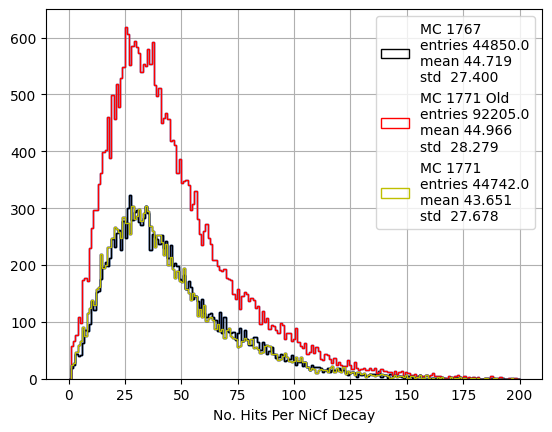

In [6]:
# Quantum Efficiency: Number Of Hits Expected In The Whole PMTs Set Per NiCf Event
# subplot = pltext.canvas(2)

# subplot(1)
pltext.hist(df_trueHits_up.groupby("event_id").count().values, 201, xylabels="No. Hits Per NiCf Decay", range=(0, 200), label="MC 1767");
pltext.hist(df_trueHits_down_old.groupby("event_id").count().values, 201, xylabels="No. Hits Per NiCf Decay", range=(0, 200), label="MC 1771 Old");
pltext.hist(df_trueHits_down.groupby("event_id").count().values, 201, xylabels="No. Hits Per NiCf Decay", range=(0, 200), label="MC 1771");

# subplot(2)
# pltext.hfit(df_trueHits_up.groupby("event_id").count().values, 21, "gaus", stats = True, residuals = True, range=(20, 40));

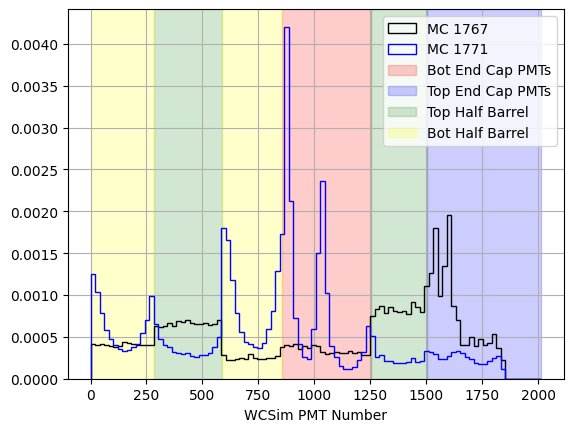

In [10]:
# subplot = pltext.canvas(2)

# subplot(1)
pltext.hist(df_trueHits_up["true_hit_pmt"].values,     100, range=(0, 2014), stats=False, density=True, xylabels="WCSim PMT Number", label="MC 1767");
pltext.hist(df_trueHits_down["true_hit_pmt"].values,   100, range=(0, 2014), stats=False, density=True, xylabels="WCSim PMT Number", label="MC 1771");

plt.axvspan(855, 1254,  color="red", alpha=0.2, label="Bot End Cap PMTs")
plt.axvspan(1501, 2014, color="blue", alpha=0.2, label="Top End Cap PMTs")
plt.axvspan(285, 589,  color="forestgreen", alpha=0.2, label="Top Half Barrel")
plt.axvspan(1254, 1501,  color="forestgreen", alpha=0.2)
plt.axvspan(0, 285,  color="yellow", alpha=0.2, label="Bot Half Barrel")
plt.axvspan(589, 855,  color="yellow", alpha=0.2)
plt.legend();

# subplot(2)
# pltext.hist(df_trueHits_down["true_hit_pmt"].values,   100, range=(0, 1843), stats=False, density=False, xylabels="WCSim PMT Number", label="MC 1771");

# plt.axvspan(855, 1254,  color="red", alpha=0.2, label="Bot End Cap PMTs")
# plt.axvspan(1501, 1843, color="blue", alpha=0.2, label="Top End Cap PMTs")
# plt.axvspan(285, 589,  color="forestgreen", alpha=0.2, label="Top Half Barrel")
# plt.axvspan(1254, 1501,  color="forestgreen", alpha=0.2)
# plt.axvspan(0, 285,  color="yellow", alpha=0.2, label="Bot Half Barrel")
# plt.axvspan(589, 855,  color="yellow", alpha=0.2)
# plt.legend();

# Comparison

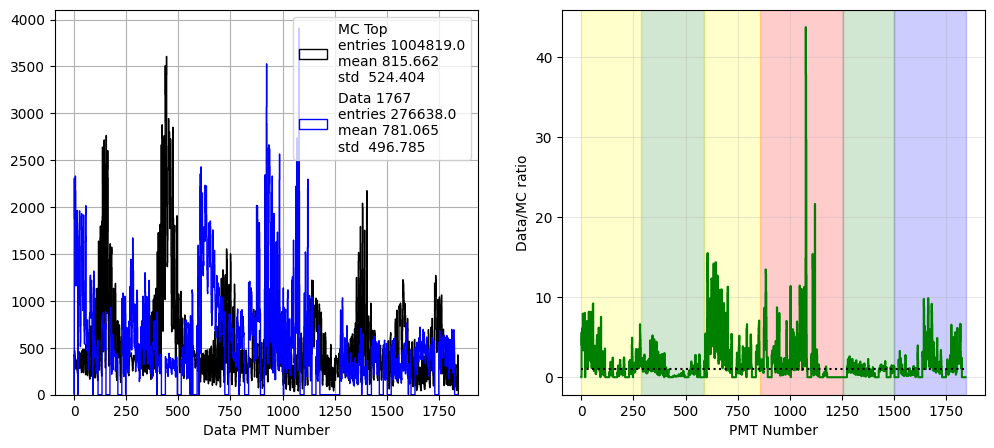

In [ ]:
v_wcsim, b_wcsim = np.histogram(df_trueHits_up["true_hit_pmt"].values, 2014, range=(0, 2014));
v_datas, b_datas = np.histogram(pmt_id,                                2014, range=(0, 2014));

N_nicf = v_wcsim.sum()
N_bkg  = v_datas.sum()
bins = np.arange(0, 100)

# --- Factor de escala global (regla de tres) ---
scale_factor = len(df_trueHits_up["true_hit_pmt"].values)/len(pmt_id)

# --- Dibujar comparación (barras) ---
bin_centers = 0.5 * (bins[:-1] + bins[1:])

subplot = pltext.canvas(2)

subplot(1)
v_wcsim, b_wcsim, _ = pltext.hist(df_trueHits_up["true_hit_pmt"].values, 2014, range=(0, 2014), xylabels="WCSim PMT Number", label="MC 1767");
v_datas, b_datas, _ = pltext.hist(pmt_id,                                2014, range=(0, 2014), xylabels="Data PMT Number", weights=np.ones_like(pmt_id) * scale_factor, label="Data 1767");

subplot(2)
bin_centers = 0.5 * (b_wcsim[1:] + b_wcsim[:-1])
ratio = np.divide(v_datas, v_wcsim)
plt.step(bin_centers, ratio, where='mid', color='green')
plt.ylabel("Data/MC ratio")
plt.xlabel("PMT Number")
plt.grid(alpha=0.3)
plt.hlines(1.0, 0, 2014, linestyles=":", color="k");

plt.axvspan(855, 1254,  color="red", alpha=0.2, label="Bot End Cap PMTs")
plt.axvspan(1501, 2014, color="blue", alpha=0.2, label="Top End Cap PMTs")
plt.axvspan(285, 589,  color="forestgreen", alpha=0.2, label="Top Half Barrel")
plt.axvspan(1254, 1501,  color="forestgreen", alpha=0.2)
plt.axvspan(0, 285,  color="yellow", alpha=0.2, label="Bot Half Barrel")
plt.axvspan(589, 855,  color="yellow", alpha=0.2)

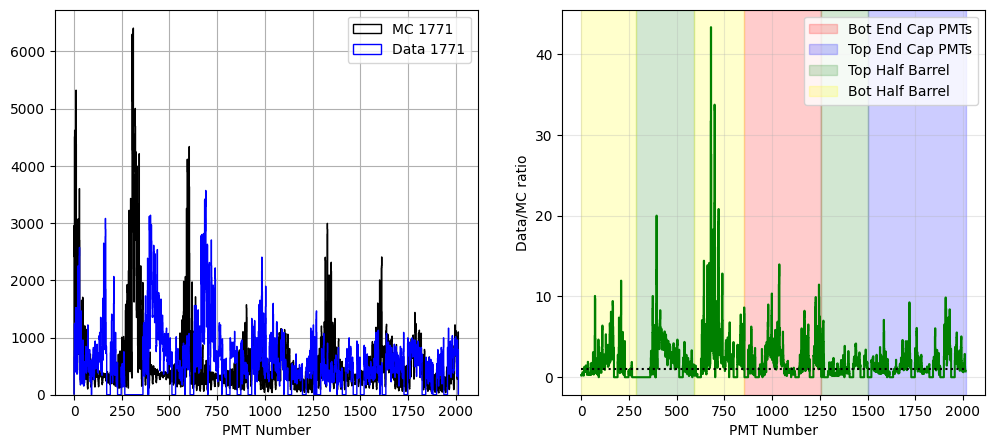

In [ ]:
v_wcsim, b_wcsim = np.histogram(df_trueHits_down["true_hit_pmt"].values, 2014, range=(0, 2014));
v_datas, b_datas = np.histogram(pmt_id,                                  2014, range=(0, 2014));

N_nicf = v_wcsim.sum()
N_bkg  = v_datas.sum()
bins = np.arange(0, 2014)

# --- Factor de escala global (regla de tres) ---
scale_factor = len(df_trueHits_down["true_hit_pmt"].values)/len(pmt_id)

# --- Dibujar comparación (barras) ---
bin_centers = 0.5 * (bins[:-1] + bins[1:])

subplot = pltext.canvas(2)

subplot(1)
v_wcsim, b_wcsim, _ = pltext.hist(df_trueHits_down["true_hit_pmt"].values, 2014, range=(0, 2014), stats=False, xylabels="PMT Number", label="MC 1771");
v_datas, b_datas, _ = pltext.hist(pmt_id,                                  2014, range=(0, 2014), stats=False, xylabels="PMT Number", weights=np.ones_like(pmt_id) * scale_factor, label="Data 1771");

subplot(2)
bin_centers = 0.5 * (b_wcsim[1:] + b_wcsim[:-1])
ratio = np.divide(v_datas, v_wcsim)

plt.step(bin_centers, ratio, where='mid', color='green')
plt.ylabel("Data/MC ratio")
plt.xlabel("PMT Number")
plt.grid(alpha=0.3)
plt.hlines(1.0, 0, 2014, linestyles=":", color="k");

plt.axvspan(855, 1254,  color="red", alpha=0.2, label="Bot End Cap PMTs")
plt.axvspan(1501, 2014, color="blue", alpha=0.2, label="Top End Cap PMTs")
plt.axvspan(285, 589,  color="forestgreen", alpha=0.2, label="Top Half Barrel")
plt.axvspan(1254, 1501,  color="forestgreen", alpha=0.2)
plt.axvspan(0, 285,  color="yellow", alpha=0.2, label="Bot Half Barrel")
plt.axvspan(589, 855,  color="yellow", alpha=0.2)
plt.legend();

# Comparison Without Gaps

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json

# Cargar los datos de gaps del análisis anterior
with open('/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim_old/install/npz/gap_analysis_data.json', 'r') as f:
    gap_data = json.load(f)

In [7]:
invalid_pmt_id = []
for i in range(len(gap_data["gaps_detalle"])):
    invalid_pmt_id.append(gap_data["gaps_detalle"][i]["numeros_faltantes"])

invalid_pmt_id = np.concatenate(invalid_pmt_id)

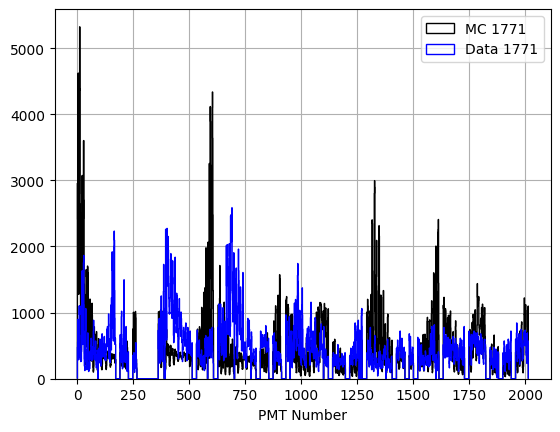

In [32]:
v_wcsim, b_wcsim = np.histogram([i for i in df_trueHits_down["true_hit_pmt"].values if i not in invalid_pmt_id], 2014, range=(0, 2014));
v_datas, b_datas = np.histogram(pmt_id,                                  2014, range=(0, 2014));

N_nicf = v_wcsim.sum()
N_bkg  = v_datas.sum()
bins = np.arange(0, 2014)

# --- Factor de escala global (regla de tres) ---
scale_factor = len([i for i in df_trueHits_down["true_hit_pmt"].values if i not in invalid_pmt_id])/len(pmt_id)

# --- Dibujar comparación (barras) ---
bin_centers = 0.5 * (bins[:-1] + bins[1:])

v_wcsim, b_wcsim, _ = pltext.hist([i for i in df_trueHits_down["true_hit_pmt"].values if i not in invalid_pmt_id], 2014, range=(0, 2014), stats=False, xylabels="PMT Number", label="MC 1771");
v_datas, b_datas, _ = pltext.hist(pmt_id,                                                                          2014, range=(0, 2014), stats=False, xylabels="PMT Number", weights=np.ones_like(pmt_id) * scale_factor, label="Data 1771");


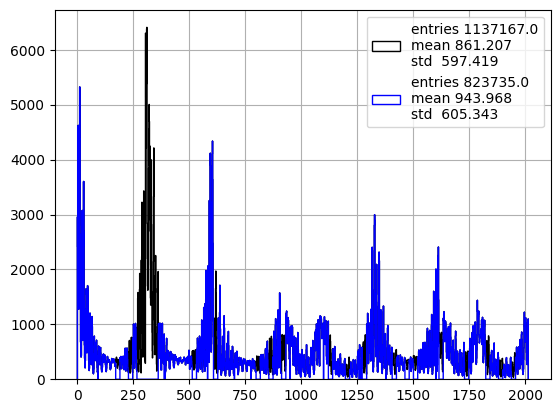

In [31]:
pltext.hist(df_trueHits_down["true_hit_pmt"].values,                                         2014, range=(0, 2013));
pltext.hist([i for i in df_trueHits_down["true_hit_pmt"].values if i not in invalid_pmt_id], 2014, range=(0, 2013));

# Event Display Exploration

In [8]:
#1) make an instance of the event display class
eventDisplay = EventDisplay() 

#2) start by loading in the CSV file for how the mPMTs are mapped to 2d event display
#unwraps based on the mPMT slot ID 
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')

#mask out mPMT slots - newer WCSim doesn't have these mPMTs loaded  
#WCTE slot numbering
# eventDisplay.mask_mPMTs([45,77,79,27,32,85,91,99,12,14,16,18])
#WCSim container numbering
# eventDisplay.mask_mPMTs([20,73,38,49,55,65,67,33,71,92,101,95])

#3) load the WCSim mapping tube no to slot number
#for WCSim using the numpy output we need the mapping between the tube_number in WCSim and the slot and mPMT number in the detector
#this can be obtained from the geofile that WCSim produces 
#This changes if the CDS is implemented or not
eventDisplay.load_wcsim_tubeno_mapping("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/geofile_NuPRISMBeamTest_16cShort_mPMT.txt")

(2014,)
[89  8  8 ... 21 38 39]


(2014,)


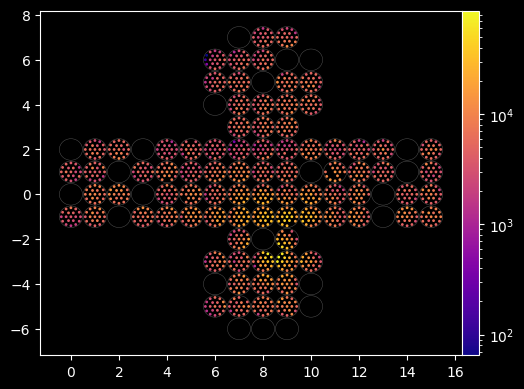

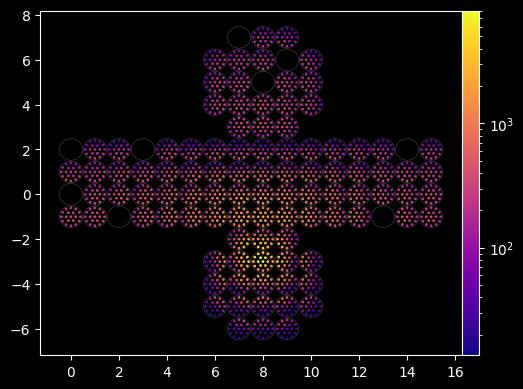

In [10]:
data_to_plot = real_events_1771["hit_pmt_charges"]

#map from the tube number to the mPMT slot and position number
data_to_plot = eventDisplay.process_data(real_events_1771["hit_mpmt_slot_ids"], real_events_1771["hit_pmt_position_ids"], data_to_plot)
eventDisplay.plotEventDisplay(data_to_plot,color_norm=colors.LogNorm(), style= "dark_background")

plt.style.use('default');
pltext.style()

data = df_digiHits_down
tube_no = data["digi_hit_pmt"] + 1
data_to_plot = data["digi_hit_charge"]

#map from the tube number to the mPMT slot and position number
mPMT_id_1771, PMT_pos_1771 = eventDisplay.map_wcsim_tubeno_to_slot_pmt_id(tube_no)
data_to_plot = eventDisplay.process_data(mPMT_id_1771, PMT_pos_1771, data_to_plot)
eventDisplay.plotEventDisplay(data_to_plot,color_norm=colors.LogNorm(), style= "dark_background")

plt.style.use('default');
pltext.style()

# DigiHits

[89  8  8 ... 21 38 39]


/tmp/ipykernel_2668002/3934201376.py:61: RuntimeWarning: invalid value encountered in divide
  ratio = np.divide(v_datas, v_wcsim)


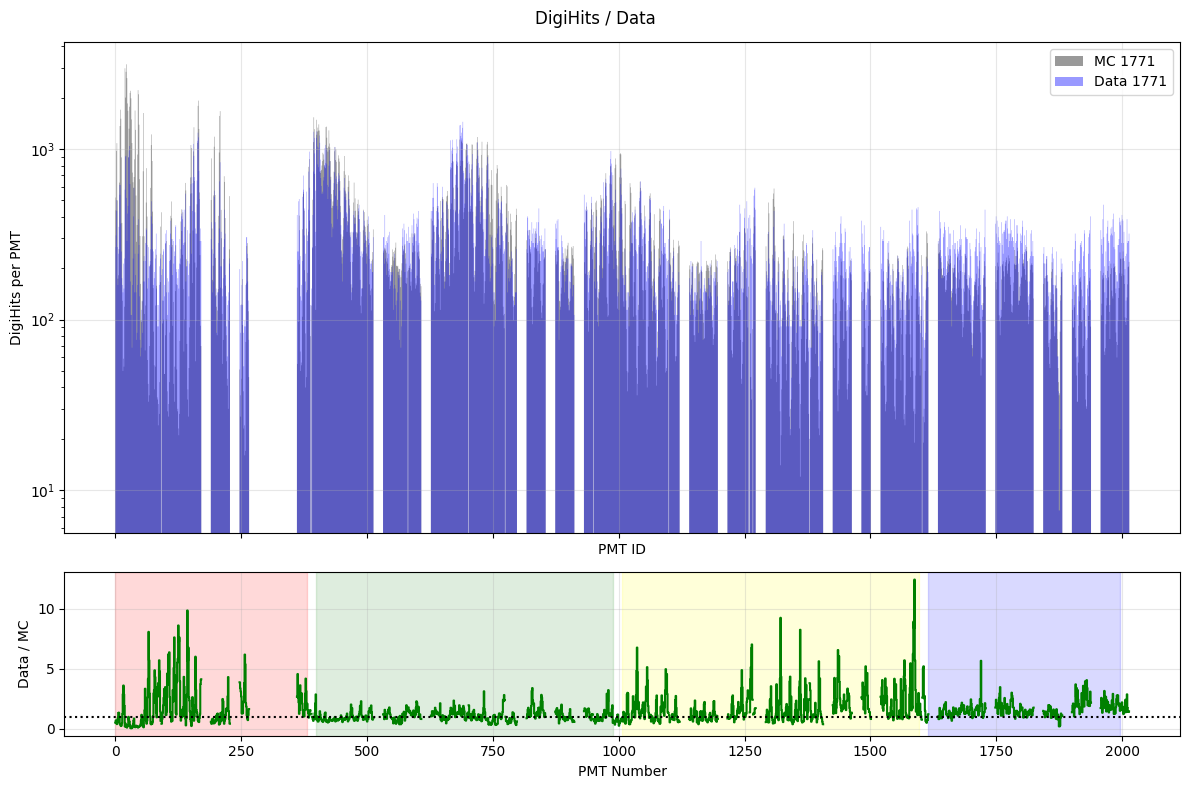

In [30]:
data = df_digiHits_down
tube_no = data["digi_hit_pmt"] + 1
mPMT_id_1771, PMT_pos_1771 = eventDisplay.map_wcsim_tubeno_to_slot_pmt_id(tube_no)

v_wcsim, b_wcsim = np.histogram([i for i in mPMT_id_1771*19 + PMT_pos_1771 if i not in invalid_pmt_id], 2014, range=(0, 2014));
v_datas, b_datas = np.histogram(pmt_id_1771,                                                            2014, range=(0, 2014));

# --- Factor de escala global (regla de tres) ---
scale_factor = len([i for i in mPMT_id_1771*19 + PMT_pos_1771 if i not in invalid_pmt_id])/len(pmt_id_1771)

# subplot = pltext.canvas(2)
# plt.suptitle("DigiHits/Data")

# subplot(1)
# v_wcsim, b_wcsim, _ = pltext.hist([i for i in mPMT_id_1771*19 + PMT_pos_1771 if i not in invalid_pmt_id], 2014, range=(0, 2014), histtype="stepfilled", alpha=0.4, xylabels="WCSim PMT Number", label="MC 1771", ylog=True);
# v_datas, b_datas, _ = pltext.hist(pmt_id_1771,                         2014, range=(0, 2014), histtype="stepfilled", alpha=0.4, xylabels="PMT Number", weights=np.ones_like(pmt_id_1771) * scale_factor, label="Data 1771", ylog=True);

# # plt.axvspan(0, 20*19,  color="red", alpha=0.2, label="Bot End Cap PMTs")
# # plt.axvspan(85*19, 105*19, color="blue", alpha=0.2, label="Top End Cap PMTs")
# # plt.axvspan(21*19, 52*19,  color="forestgreen", alpha=0.2, label="Bot Half Barrel")
# # plt.axvspan(53*19, 84*19,  color="yellow", alpha=0.2, label="Top Half Barrel")

# subplot(2)
# bin_centers = 0.5 * (b_wcsim[1:] + b_wcsim[:-1])
# ratio = np.divide(v_datas, v_wcsim)
# plt.step(bin_centers, ratio, where='mid', color='green')
# plt.ylabel("Data/MC ratio")
# plt.xlabel("PMT Number")
# plt.grid(alpha=0.3)
# plt.hlines(1.0, 0, 2014, linestyles=":", color="k");
# # plt.yscale("log");
# # plt.ylim(0.01, 4.2);

# plt.axvspan(0, 20*19,      color="red", alpha=0.2, label="Bot End Cap PMTs")
# plt.axvspan(85*19, 105*19, color="blue", alpha=0.2, label="Top End Cap PMTs")
# plt.axvspan(21*19, 52*19,  color="forestgreen", alpha=0.2, label="Bot Half Barrel")
# plt.axvspan(53*19, 84*19,  color="yellow", alpha=0.2, label="Top Half Barrel")

# plt.legend();

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# --- DigiHits por PMT ---
v_wcsim, b_wcsim, _ = ax1.hist([i for i in mPMT_id_1771*19 + PMT_pos_1771 if i not in invalid_pmt_id], 2014, range=(0, 2014), histtype="stepfilled", alpha=0.4, label="MC 1771");
v_datas, b_datas, _ = ax1.hist(pmt_id_1771,                         2014, range=(0, 2014), histtype="stepfilled", alpha=0.4, weights=np.ones_like(pmt_id_1771) * scale_factor, label="Data 1771");

ax1.set_yscale("log")
ax1.set_xlabel("PMT ID")
ax1.set_ylabel("DigiHits per PMT")
ax1.legend()
ax1.grid(alpha=0.3)

# --- Ratio ---
bin_centers = 0.5 * (b_wcsim[1:] + b_wcsim[:-1])
ratio = np.zeros(2014)
ratio = np.divide(v_datas, v_wcsim)
ax2.step(bin_centers, ratio, where='mid', color='green')
ax2.axhline(1.0, linestyle=":", color="k")



ax2.set_ylabel("Data / MC")
ax2.set_xlabel("PMT Number")
ax2.grid(alpha=0.3)

# --- Regiones del detector ---
ax2.axvspan(0, 20*19,      color="red", alpha=0.15)
ax2.axvspan(21*19, 52*19,  color="forestgreen", alpha=0.15)
ax2.axvspan(53*19, 84*19,  color="yellow", alpha=0.15)
ax2.axvspan(85*19, 105*19, color="blue", alpha=0.15)

plt.suptitle("DigiHits / Data", y=0.98)
plt.tight_layout()
plt.show()

[89  8  8 ... 21 38 39]


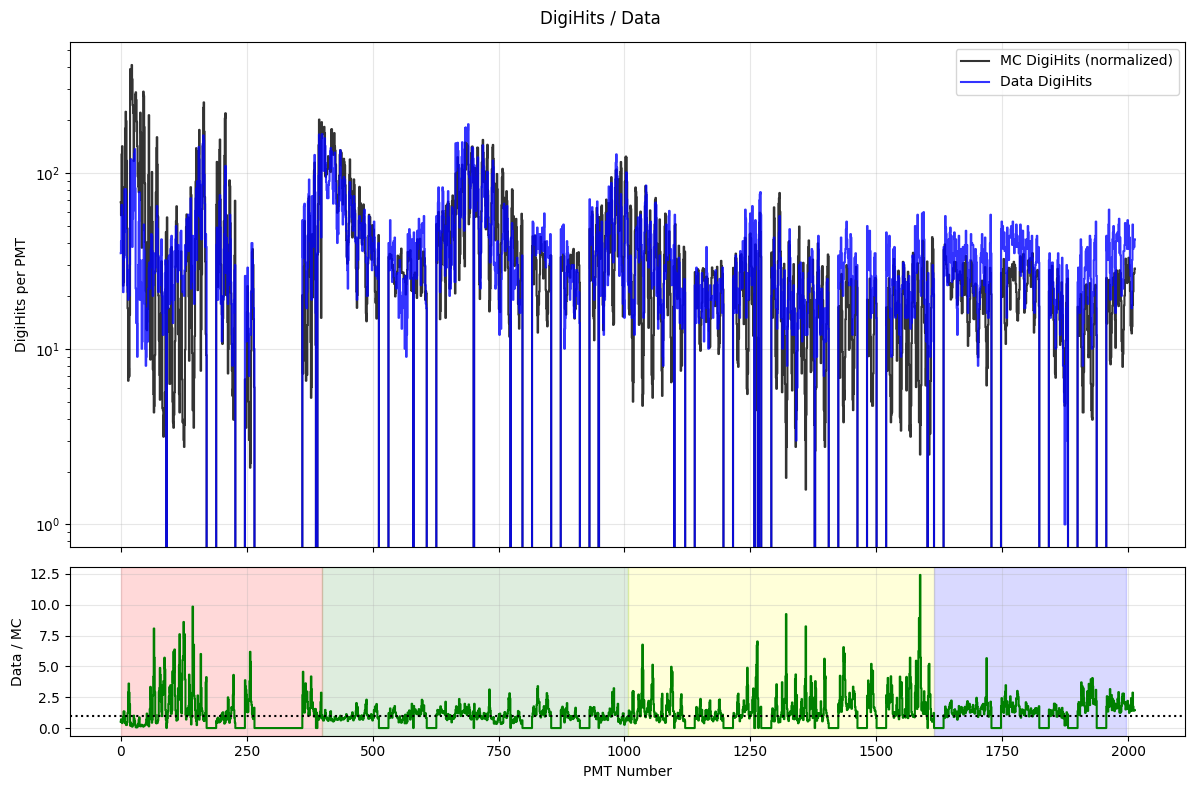

In [21]:
# ============================================================
# 1. MC: DigiHits por PMT
# ============================================================
data = df_digiHits_down
tube_no = data["digi_hit_pmt"] + 1
mPMT_id_1771, PMT_pos_1771 = eventDisplay.map_wcsim_tubeno_to_slot_pmt_id(tube_no)
mc_pmt_id = mPMT_id_1771 * 19 + PMT_pos_1771

mc_pmt_id = np.array(
    [pmt for pmt in mc_pmt_id if pmt not in invalid_pmt_id]
)

mc_digi = np.bincount(mc_pmt_id, minlength=2014)


# ============================================================
# 2. Data: DigiHits por PMT
# ============================================================

data_pmt_id = pmt_id_1771
data_digi = np.bincount(data_pmt_id, minlength=2014)


# ============================================================
# 3. Normalización global (DigiHits totales)
# ============================================================

scale_factor = data_digi.sum() / mc_digi.sum()
mc_digi_norm = mc_digi * scale_factor


# ============================================================
# 4. Ratio Data / MC
# ============================================================

mask = mc_digi_norm > 0
ratio = np.zeros(2014)
ratio[mask] = data_digi[mask] / mc_digi_norm[mask]


# ============================================================
# 5. Plot (idéntico al de PEs)
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# --- DigiHits por PMT ---
ax1.step(range(2014), mc_digi_norm, where="mid",
         label="MC DigiHits (normalized)", alpha=0.8)
ax1.step(range(2014), data_digi, where="mid",
         label="Data DigiHits", alpha=0.8)

ax1.set_yscale("log")
ax1.set_ylabel("DigiHits per PMT")
ax1.legend()
ax1.grid(alpha=0.3)

# --- Ratio ---
ax2.step(range(2014), ratio, where="mid", color="green")
ax2.axhline(1.0, linestyle=":", color="k")

ax2.set_ylabel("Data / MC")
ax2.set_xlabel("PMT Number")
ax2.grid(alpha=0.3)

# --- Regiones del detector ---
ax2.axvspan(0, 21*19,      color="red", alpha=0.15)
ax2.axvspan(21*19, 53*19,  color="forestgreen", alpha=0.15)
ax2.axvspan(53*19, 85*19,  color="yellow", alpha=0.15)
ax2.axvspan(85*19, 105*19, color="blue", alpha=0.15)

plt.suptitle("DigiHits / Data", y=0.98)
plt.tight_layout()
plt.show()


In [28]:
ratio.mean()
mse = 1/len(ratio)*np.sum([(i - ratio.mean())**2 for i in ratio])
ratio.mean(), mse

(np.float64(1.2183751422666362), np.float64(1.5745007924219514))

# trueHits

[89  8  8 ... 21 38 39]


/tmp/ipykernel_2668002/1296407481.py:25: RuntimeWarning: invalid value encountered in divide
  ratio = np.divide(v_datas, v_wcsim)


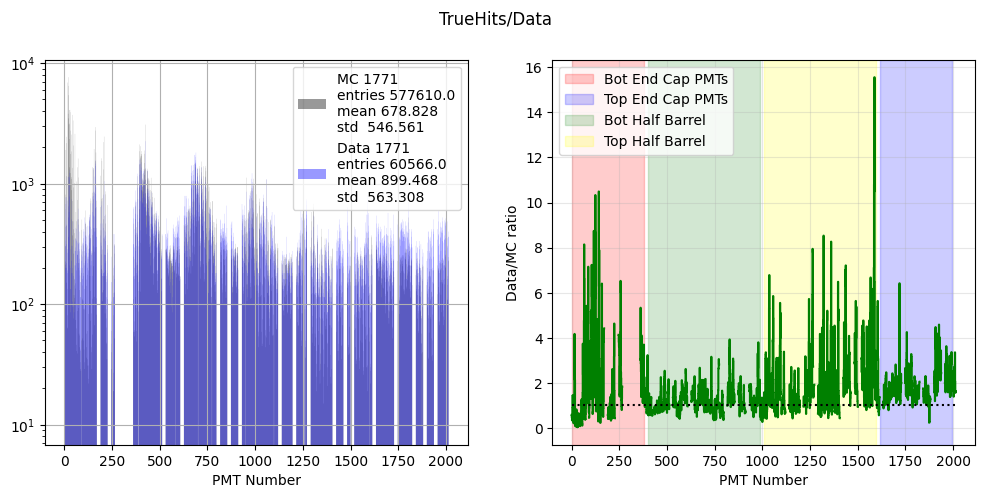

In [13]:
data = df_trueHits_down
tube_no = data["true_hit_pmt"] + 1
mPMT_id_1771, PMT_pos_1771 = eventDisplay.map_wcsim_tubeno_to_slot_pmt_id(tube_no)

v_wcsim, b_wcsim = np.histogram([i for i in mPMT_id_1771*19 + PMT_pos_1771 if i not in invalid_pmt_id], 1995, range=(0, 2014));
v_datas, b_datas = np.histogram(pmt_id_1771,                                                            1995, range=(0, 2014));

# --- Factor de escala global (regla de tres) ---
scale_factor = len([i for i in mPMT_id_1771*19 + PMT_pos_1771 if i not in invalid_pmt_id])/len(pmt_id_1771)

subplot = pltext.canvas(2)
plt.suptitle("TrueHits/Data")

subplot(1)
v_wcsim, b_wcsim, _ = pltext.hist([i for i in mPMT_id_1771*19 + PMT_pos_1771 if i not in invalid_pmt_id], 1995, range=(0, 2014), histtype="stepfilled", alpha=0.4, xylabels="WCSim PMT Number", label="MC 1771", ylog=True);
v_datas, b_datas, _ = pltext.hist(pmt_id_1771,                         1995, range=(0, 2014), histtype="stepfilled", alpha=0.4, xylabels="PMT Number", weights=np.ones_like(pmt_id_1771) * scale_factor, label="Data 1771", ylog=True);

# plt.axvspan(0, 20*19,  color="red", alpha=0.2, label="Bot End Cap PMTs")
# plt.axvspan(85*19, 105*19, color="blue", alpha=0.2, label="Top End Cap PMTs")
# plt.axvspan(21*19, 52*19,  color="forestgreen", alpha=0.2, label="Bot Half Barrel")
# plt.axvspan(53*19, 84*19,  color="yellow", alpha=0.2, label="Top Half Barrel")

subplot(2)
bin_centers = 0.5 * (b_wcsim[1:] + b_wcsim[:-1])
ratio = np.divide(v_datas, v_wcsim)
plt.step(bin_centers, ratio, where='mid', color='green')
plt.ylabel("Data/MC ratio")
plt.xlabel("PMT Number")
plt.grid(alpha=0.3)
plt.hlines(1.0, 0, 2014, linestyles=":", color="k");
# plt.yscale("log");
# plt.ylim(0.01, 4.2);

plt.axvspan(0, 20*19,      color="red", alpha=0.2, label="Bot End Cap PMTs")
plt.axvspan(85*19, 105*19, color="blue", alpha=0.2, label="Top End Cap PMTs")
plt.axvspan(21*19, 52*19,  color="forestgreen", alpha=0.2, label="Bot Half Barrel")
plt.axvspan(53*19, 84*19,  color="yellow", alpha=0.2, label="Top Half Barrel")

plt.legend();

[89  8  8 ... 21 38 39]


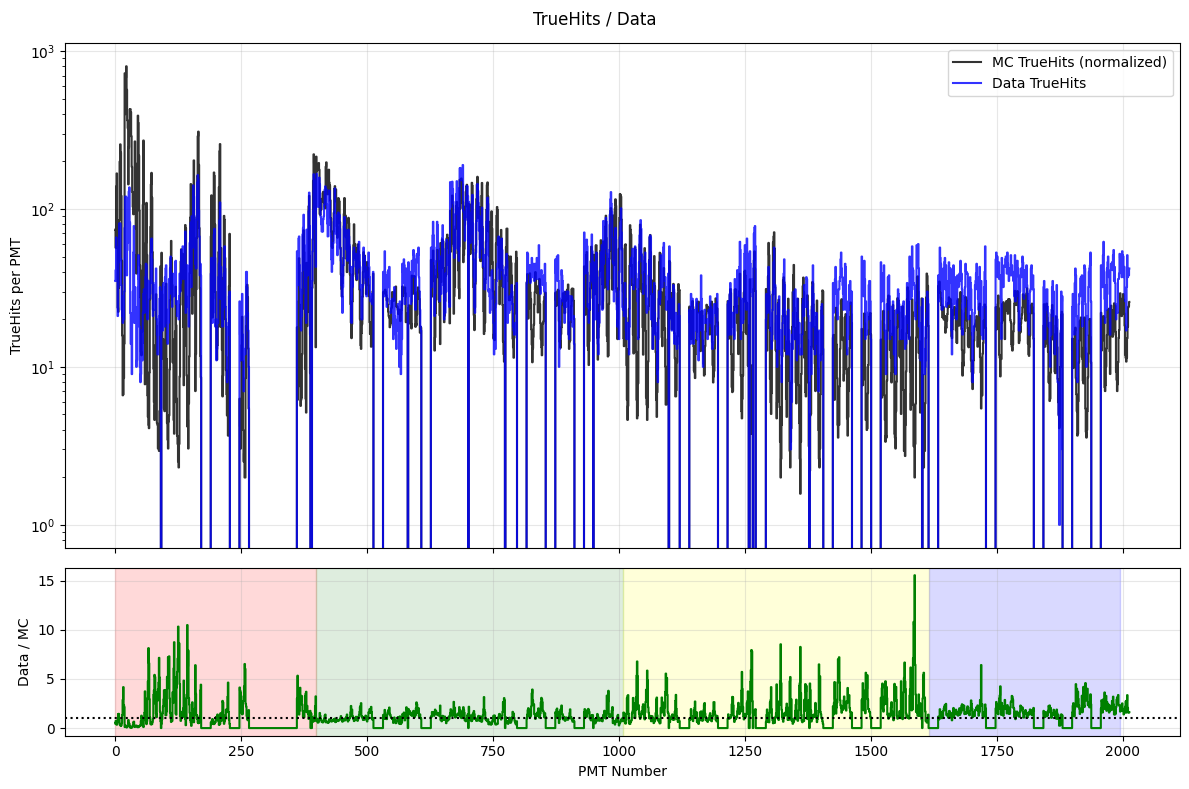

In [29]:
# ============================================================
# 1. MC: TrueHits por PMT
# ============================================================
data = df_trueHits_down
tube_no = data["true_hit_pmt"] + 1
mPMT_id_1771, PMT_pos_1771 = eventDisplay.map_wcsim_tubeno_to_slot_pmt_id(tube_no)
mc_pmt_id = mPMT_id_1771 * 19 + PMT_pos_1771

mc_pmt_id = np.array(
    [pmt for pmt in mc_pmt_id if pmt not in invalid_pmt_id]
)

mc_digi = np.bincount(mc_pmt_id, minlength=2014)


# ============================================================
# 2. Data: TrueHits por PMT
# ============================================================

data_pmt_id = pmt_id_1771
data_digi = np.bincount(data_pmt_id, minlength=2014)


# ============================================================
# 3. Normalización global (TrueHits totales)
# ============================================================

scale_factor = data_digi.sum() / mc_digi.sum()
mc_digi_norm = mc_digi * scale_factor


# ============================================================
# 4. Ratio Data / MC
# ============================================================

mask = mc_digi_norm > 0
ratio = np.zeros(2014)
ratio[mask] = data_digi[mask] / mc_digi_norm[mask]


# ============================================================
# 5. Plot (idéntico al de PEs)
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# --- TrueHits por PMT ---
ax1.step(range(2014), mc_digi_norm, where="mid",
         label="MC TrueHits (normalized)", alpha=0.8)
ax1.step(range(2014), data_digi, where="mid",
         label="Data TrueHits", alpha=0.8)

ax1.set_yscale("log")
ax1.set_ylabel("TrueHits per PMT")
ax1.legend()
ax1.grid(alpha=0.3)

# --- Ratio ---
ax2.step(range(2014), ratio, where="mid", color="green")
ax2.axhline(1.0, linestyle=":", color="k")

ax2.set_ylabel("Data / MC")
ax2.set_xlabel("PMT Number")
ax2.grid(alpha=0.3)

# --- Regiones del detector ---
ax2.axvspan(0, 21*19,      color="red", alpha=0.15)
ax2.axvspan(21*19, 53*19,  color="forestgreen", alpha=0.15)
ax2.axvspan(53*19, 85*19,  color="yellow", alpha=0.15)
ax2.axvspan(85*19, 105*19, color="blue", alpha=0.15)

plt.suptitle("TrueHits / Data", y=0.98)
plt.tight_layout()
plt.show()

In [30]:
ratio.mean()
mse = 1/len(ratio)*np.sum([(i - ratio.mean())**2 for i in ratio])
ratio.mean(), mse

(np.float64(1.3631272251103252), np.float64(2.043750762948213))

# PMT Charge Studies

In [53]:
real_events_1771.groupby("hit_mpmt_slot_ids").sum()["hit_pmt_charges"].argmax()

np.int64(8)

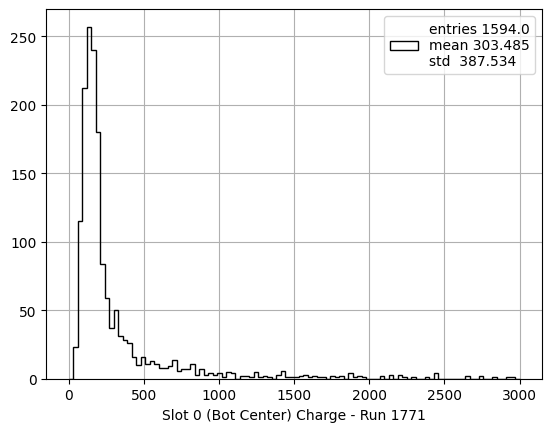

In [58]:
pltext.hist(real_events_1771["hit_pmt_charges"][real_events_1771["hit_mpmt_slot_ids"] == 8], 100, range=(0, 3e3), ylog=False, xylabels="Slot 0 (Bot Center) Charge - Run 1771");

In [62]:
outdir = "../figures_pmt"
os.makedirs(outdir, exist_ok=True)

mpmt = 8

for pmt in range(19):
    pltext.hist(
        real_events_1771["hit_pmt_charges"][
            (real_events_1771["hit_mpmt_slot_ids"] == mpmt) &
            (real_events_1771["hit_pmt_position_ids"] == pmt)
        ],
        100,
        xylabels=f"Slot {mpmt} PMT {pmt} Hit Charge - Run 1771"
    )
    
    plt.savefig(os.path.join(outdir, f"mPMT{mpmt}-PMT{pmt}-charge.png"))
    plt.close()

(2014,)


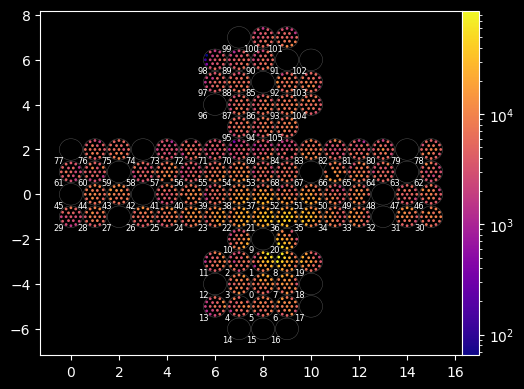

In [54]:
data_to_plot = real_events_1771["hit_pmt_charges"]


#map from the tube number to the mPMT slot and position number
data_to_plot = eventDisplay.process_data(real_events_1771["hit_mpmt_slot_ids"], real_events_1771["hit_pmt_position_ids"], data_to_plot)
eventDisplay.plotEventDisplay(data_to_plot,color_norm=colors.LogNorm(), style= "dark_background")

slot_ids = np.arange(eventDisplay.nmPMTs)
eventDisplay.label_mPMTs(slot_ids)

plt.style.use('default');
pltext.style()

# Summed Charge Sutides

In [95]:
summed_charge_per_pmt_data = real_events_1771.groupby("pmt_id")["hit_pmt_charges"].sum()
summed_charge_per_pmt_mc   = df_digiHits_down.groupby("digi_hit_pmt")["digi_hit_charge"].sum()

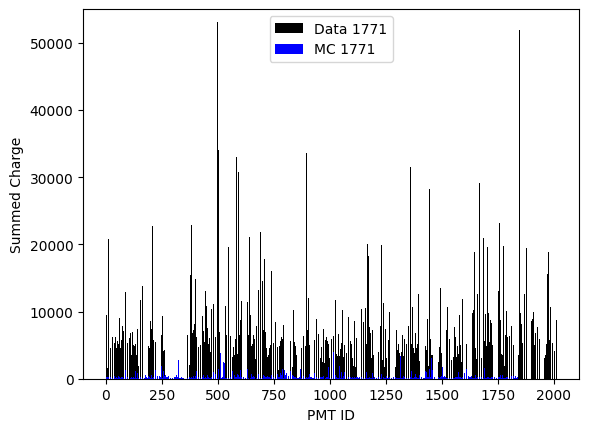

In [96]:
plt.bar(x=real_events_1771["pmt_id"].unique(), height=summed_charge_per_pmt_data, label="Data 1771");
plt.bar(x=df_digiHits_down["digi_hit_pmt"].unique(), height=summed_charge_per_pmt_mc, label="MC 1771")
plt.ylim(0, 55e3);
plt.xlabel("PMT ID");
plt.ylabel("Summed Charge");
plt.legend();

# Gain Calibration Comparison

In [11]:
for i in [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]:
    df = pd.DataFrame(np.load(f"/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/gain_calibration_elena_v2/results/High_statistics_run2307_chunk{i}.npz")["results"])
    if i == 0:
        df_result = df
    else:
        df_result = pd.concat([df_result, df], ignore_index=True)

In [12]:
df_result["pmt_id"] = df_result["slot_id"]*19 + df_result["pos_id"]

In [13]:
df_result.head()

,card_id,slot_id,channel_id,pos_id,pedestal_mean,pedestal_sigma,N_pedestal,spe_mean,spe_sigma,N_spe,gain,gain_error,pulse_ratio,mu_pe,chi2ndof_spe,pmt_id
0,100,24,0,17,0.996903,1.489627,42143,138.419583,43.554882,2479,137.422681,0.855365,0.083312,0.086988,0.629715,473
1,100,24,10,10,0.768377,1.784658,35232,144.542683,58.116755,5927,143.774306,0.731279,0.218443,0.246467,0.919703,466
2,100,24,11,11,1.469578,1.088433,35570,139.355989,54.727406,5455,137.886412,0.716594,0.210338,0.236150,1.135518,467
3,100,24,12,4,0.860835,1.339466,37309,147.698672,52.478615,5005,146.837836,0.720340,0.177919,0.195916,0.938746,460
4,100,24,13,12,1.134582,1.511565,37038,145.677018,45.667930,5111,144.542436,0.623769,0.183437,0.202651,1.165287,468


In [14]:
df_elena = df_result[["pmt_id", "gain"]]
df_elena

,pmt_id,gain
0,473,137.422681
1,466,143.774306
2,467,137.886412
3,460,146.837836
4,468,144.542436
...,...,...
1510,1717,142.444433
1511,1718,146.970561
1512,1712,142.905340
1513,1719,142.983762


In [15]:
df_merge = pd.merge(real_events_1771, df_elena, how="inner", on=["pmt_id"])
df_merge["calibrated_charge_PEs"] = df_merge["hit_pmt_charges"].values/df_merge["gain"].values

In [16]:
df_merge

,event_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_card_ids,hit_mpmt_slot_ids,hit_pmt_channel_ids,hit_pmt_position_ids,pmt_id,gain,calibrated_charge_PEs
0,3,297882.315932,118,96,8,13,12,164,146.301097,0.806556
1,3,297882.713238,284,12,1,6,8,27,145.721876,1.948918
2,3,297883.016150,145,101,20,17,15,395,138.838531,1.044379
3,3,297883.287354,195,12,1,5,7,26,144.234077,1.351969
4,3,297884.476903,133,101,20,12,4,384,140.478302,0.946765
...,...,...,...,...,...,...,...,...,...,...
55862,13117,2167.260354,172,38,65,0,17,1252,139.302801,1.234720
55863,13117,2168.544721,56,73,31,17,15,604,138.956036,0.403005
55864,13117,2169.802774,83,28,56,15,5,1069,142.325139,0.583172
55865,13117,2170.098542,73,104,40,0,17,777,140.339135,0.520169


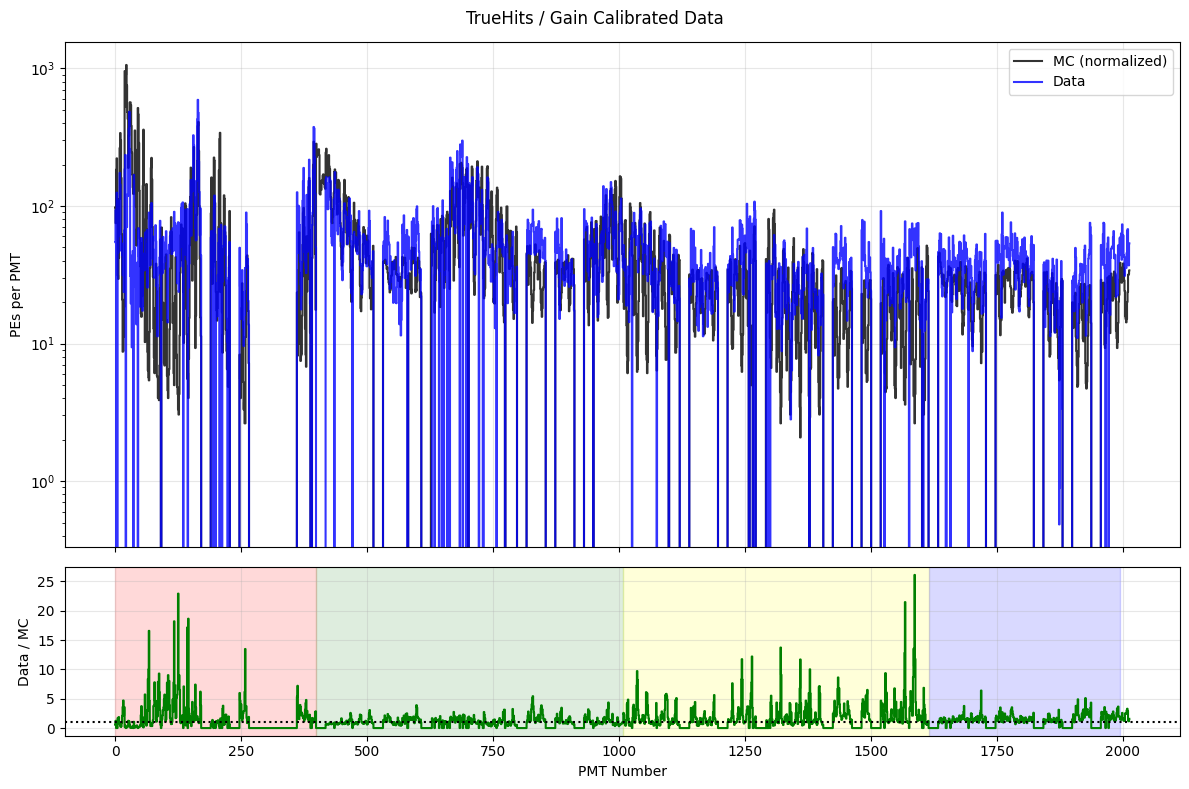

In [32]:
# PMT global ID en WCSim
mc_pmt_id = mPMT_id_1771 * 19 + PMT_pos_1771

# Eliminar PMTs inválidos si aplica
mc_pmt_id = np.array(
    [pmt for pmt in mc_pmt_id if pmt not in invalid_pmt_id]
)

# Número de PEs MC por PMT
mc_pe = np.bincount(mc_pmt_id, minlength=2014)


# ============================================================
# 2. Data: charge/gain -> PEs por PMT
# ============================================================

pe_data = (
    df_merge
    .groupby("pmt_id")["calibrated_charge_PEs"]
    .sum()
)

# Aseguramos vector completo de 2014 PMTs
data_pe = np.zeros(2014)
data_pe[pe_data.index.values] = pe_data.values


# ============================================================
# 3. Normalización global (PEs totales)
# ============================================================

total_pe_data = data_pe.sum()
total_pe_mc   = mc_pe.sum()

scale_factor = total_pe_data / total_pe_mc

mc_pe_norm = mc_pe * scale_factor


# ============================================================
# 4. Ratio Data / MC
# ============================================================

# Evitar divisiones por cero
mask = mc_pe_norm > 0

ratio = np.zeros(2014)
ratio[mask] = data_pe[mask] / mc_pe_norm[mask]


# ============================================================
# 5. Plot
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# --- PEs por PMT ---
ax1.step(range(2014), mc_pe_norm, where="mid",
         label="MC (normalized)", alpha=0.8)
ax1.step(range(2014), data_pe, where="mid",
         label="Data", alpha=0.8)

ax1.set_yscale("log")
ax1.set_ylabel("PEs per PMT")
ax1.legend()
ax1.grid(alpha=0.3)

# --- Ratio ---
ax2.step(range(2014), ratio, where="mid", color="green")
ax2.axhline(1.0, linestyle=":", color="k")

ax2.set_ylabel("Data / MC")
ax2.set_xlabel("PMT Number")
ax2.grid(alpha=0.3)

# --- Regiones del detector (opcional) ---
ax2.axvspan(0, 21*19,      color="red", alpha=0.15)
ax2.axvspan(21*19, 53*19,  color="forestgreen", alpha=0.15)
ax2.axvspan(53*19, 85*19,  color="yellow", alpha=0.15)
ax2.axvspan(85*19, 105*19, color="blue", alpha=0.15)

plt.suptitle("TrueHits / Gain Calibrated Data", y=0.98)
plt.tight_layout()
plt.show()

In [33]:
ratio.mean()
mse = 1/len(ratio)*np.sum([(i - ratio.mean())**2 for i in ratio])
ratio.mean(), mse

(np.float64(1.4843893032008988), np.float64(4.149445072066975))